In [ ]:
import scanpy as sc
import numpy as np
import loompy as lp
import scipy.sparse as sp
import scvelo as scv
import cellrank as cr
import tdqm

In [ ]:
#scv.set_figure_params(dpi=600, frameon=False, format='png')

In [2]:
file = '/Users/rikac/Documents/mansfield_lab/bc3306_with_vcy.h5ad'
adata = sc.read(file)

## Analysis

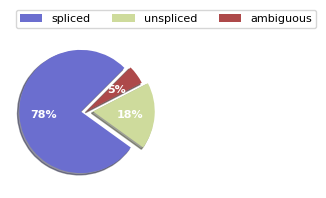

In [3]:
scv.pl.proportions(adata)

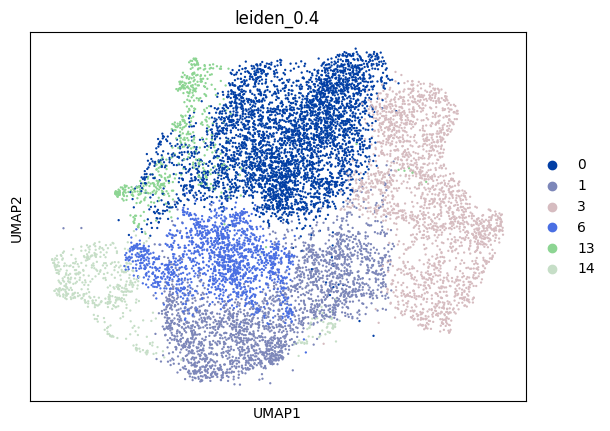

In [ ]:
# subset to pdgfra+ clusters
clusters_of_interest = ['0', '1', '3', '6', '13', '14']
subset_adata = adata[adata.obs['leiden_0.4'].isin(clusters_of_interest)].copy()
sc.pl.umap(subset_adata, color='leiden_0.4')


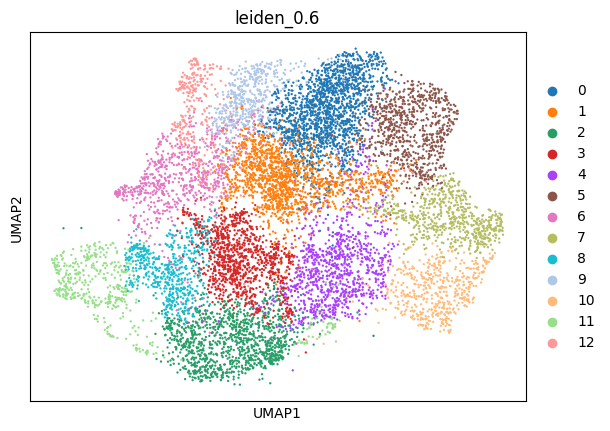

In [5]:
sc.tl.leiden(subset_adata, resolution=0.6, key_added='leiden_0.6')
sc.pl.umap(subset_adata, color='leiden_0.6')

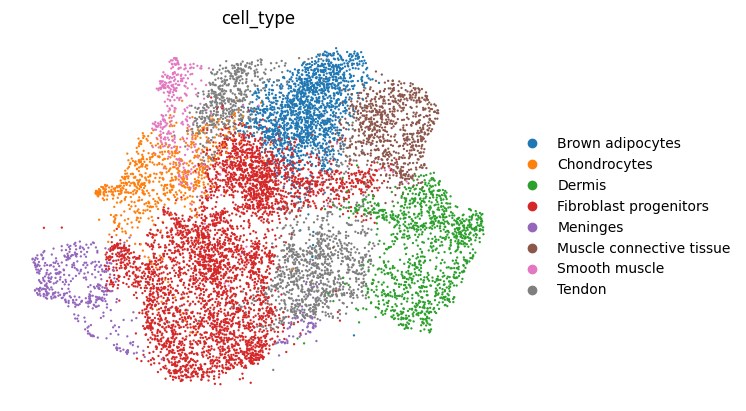

In [6]:
# cell type
cluster_mapping = {
    '0':'Brown adipocytes',
    '1':'Fibroblast progenitors',
    '2':'Fibroblast progenitors',
    '3':'Fibroblast progenitors',
    '4':'Tendon',
    '5':'Muscle connective tissue',
    '6':'Chondrocytes',
    '7':'Dermis', 
    '8':'Fibroblast progenitors',
    '9':'Tendon',
    '10':'Dermis',
    '11':'Meninges',
    '12':'Smooth muscle'
}

subset_adata.obs["cell_type"] = subset_adata.obs["leiden_0.6"].astype(str).map(cluster_mapping)

sc.pl.umap(subset_adata, color='cell_type', frameon=False)

In [7]:
# pre-processing and calculating mean and variance
scv.pp.filter_and_normalize(subset_adata)
scv.pp.moments(subset_adata, n_pcs=30, n_neighbors=30)

Normalized count data: X, spliced, unspliced.
Logarithmized X.


/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_7148/266504194.py:3: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(subset_adata, n_pcs=30, n_neighbors=30)
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


computing neighbors
    finished (0:00:22) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:12) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [8]:
scv.tl.recover_dynamics(subset_adata, n_jobs=4)

recovering dynamics (using 4/8 cores)
or disable the progress bar using `show_progress_bar=False`.


KeyboardInterrupt: 

In [9]:
# use parameters to compute actual velocities
scv.tl.velocity(subset_adata, mode="dynamical")
# compute velocities graph
scv.tl.velocity_graph(subset_adata)

computing velocities
    finished (0:00:15) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/8 cores)
    finished (0:00:13) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


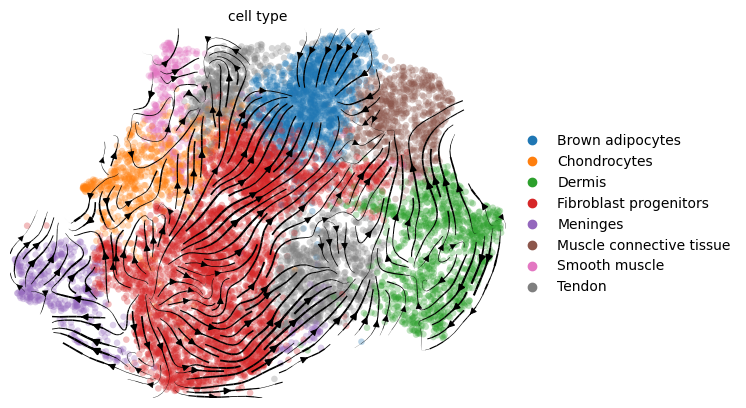

In [10]:
scv.pl.velocity_embedding_stream(subset_adata, basis='umap', color='cell_type', legend_loc='right')

In [11]:
# differential kinetics
scv.tl.velocity(subset_adata, diff_kinetics=True)
scv.tl.velocity_graph(subset_adata)

computing velocities


/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:13) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/8 cores)
    finished (0:00:41) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


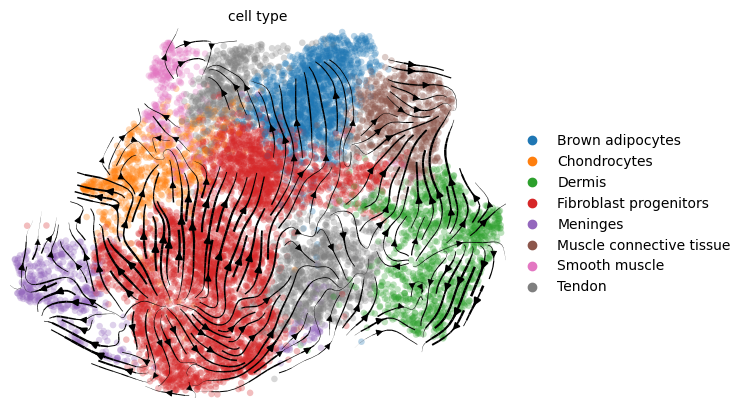

In [12]:
scv.pl.velocity_embedding_stream(subset_adata, basis='umap', color='cell_type', legend_loc='right')

computing terminal states
    identified 6 regions of root cells and 1 region of end points .
    finished (0:00:01) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


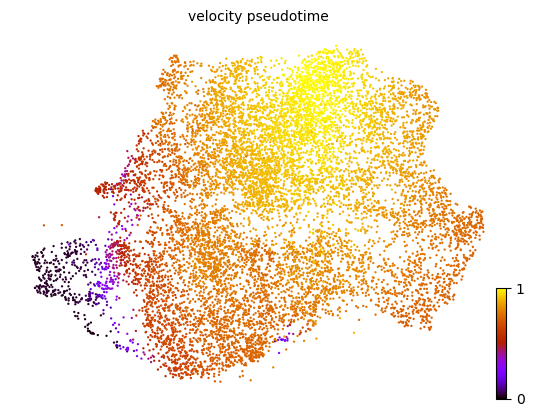

In [13]:
# velocity pseudotime
scv.tl.velocity_pseudotime(subset_adata)
scv.pl.scatter(subset_adata, color='velocity_pseudotime', cmap='gnuplot')

computing latent time using root_cells as prior
    finished (0:00:09) --> added 
    'latent_time', shared time (adata.obs)


/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


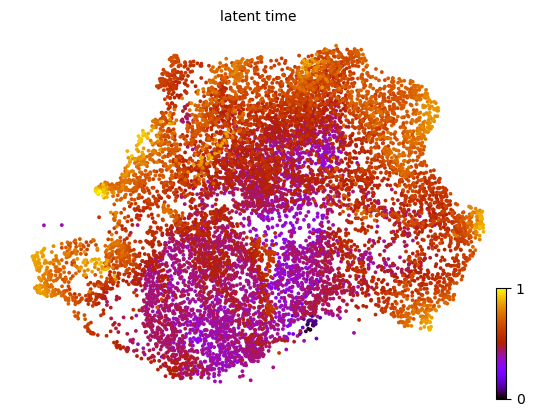

In [14]:
# latent time
scv.tl.latent_time(subset_adata)
scv.pl.scatter(subset_adata, color='latent_time', color_map='gnuplot', size=30)

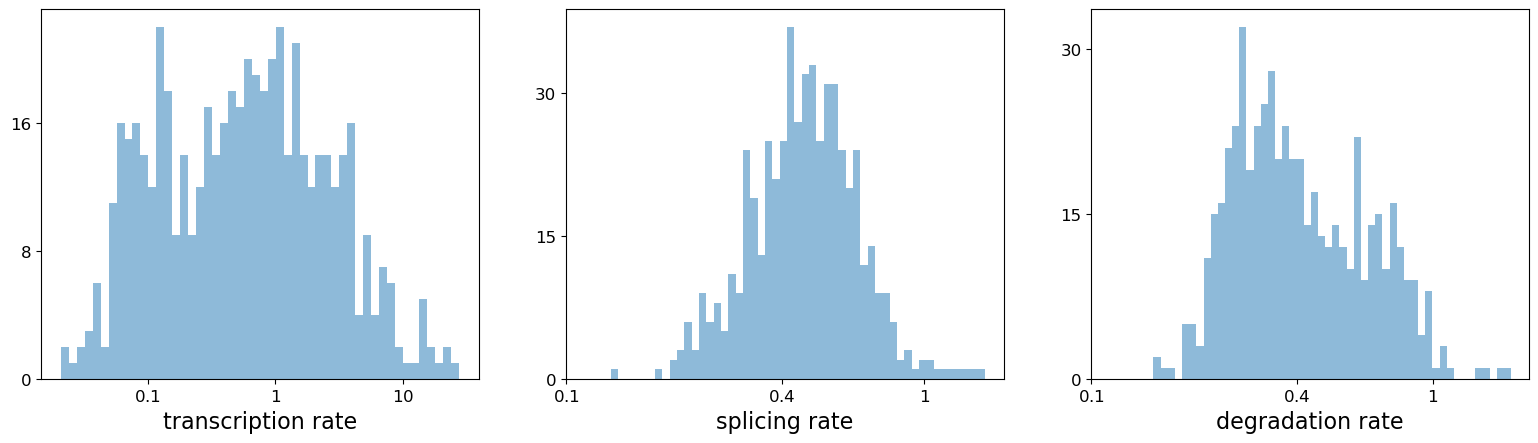

/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9366/2325981345.py:11: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  scv.get_df(subset_adata, 'fit*', dropna=True).head()


,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling
VXN,0.076560,0.033289,1.006329,0.336206,7.758812,0.489662,0.007734,0.020271,1.398136e-04,0.0,0.0,0.095499,0.023991,0.055674,0.870338,2.604375
MYBL1,0.088639,0.043104,0.561453,0.239055,6.997085,1.336217,0.030377,0.035805,2.021984e-01,0.0,0.0,0.101262,0.092177,0.122408,1.070332,1.999406
SULF1,0.739223,1.336230,0.483921,0.575330,10.975369,0.627622,0.831661,0.626110,3.569796e-01,0.0,0.0,0.457098,2.410917,1.781254,0.418857,1.555714
4930444P10RIK,0.120113,0.089692,0.868796,0.243968,4.603027,0.701999,0.031643,0.060739,9.369565e-02,0.0,0.0,0.348457,0.102906,0.175153,1.362291,1.893774
TFAP2B,0.048514,0.038837,0.440819,0.215999,5.170155,1.503398,0.026264,0.029785,6.413162e-07,0.0,0.0,0.225420,0.086692,0.093856,1.467731,2.424360


In [15]:
# kinetic rates
df = subset_adata.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]

kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

scv.get_df(subset_adata, 'fit*', dropna=True).head()

The estimated gene-specific parameters comprise rates of transription (`fit_alpha`), splicing (`fit_beta`), degradation (`fit_gamma`), switching time point (`fit_t_`), a scaling parameter to adjust for under-represented unspliced reads (`fit_scaling`), standard deviation of unspliced and spliced reads (`fit_std_u`, `fit_std_s`), the gene likelihood (`fit_likelihood`), inferred steady-state levels (`fit_steady_u`, `fit_steady_s`) with their corresponding p-values (`fit_pval_steady_u`, `fit_pval_steady_s`), the overall model variance (`fit_variance`), and a scaling factor to align the gene-wise latent times to a universal, gene-shared latent time (`fit_alignment_scaling`).

/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


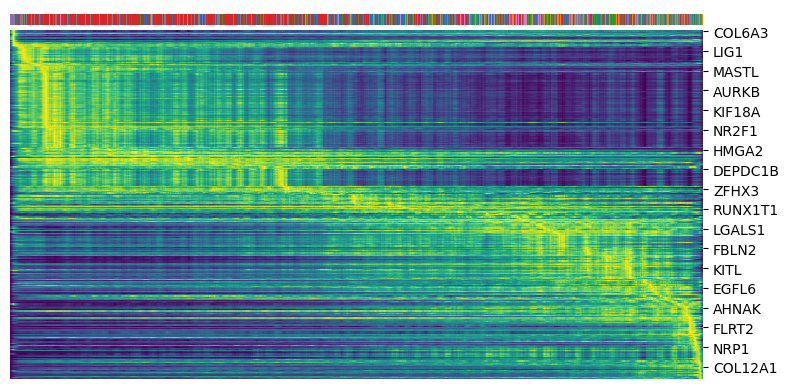

In [16]:
# top-likelihood genes across all cell types
top_genes = subset_adata.var['fit_likelihood'].sort_values(ascending=False).index[:300]
scv.pl.heatmap(subset_adata, var_names=top_genes, sortby='latent_time', col_color='cell_type', n_convolve=100)

/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWa

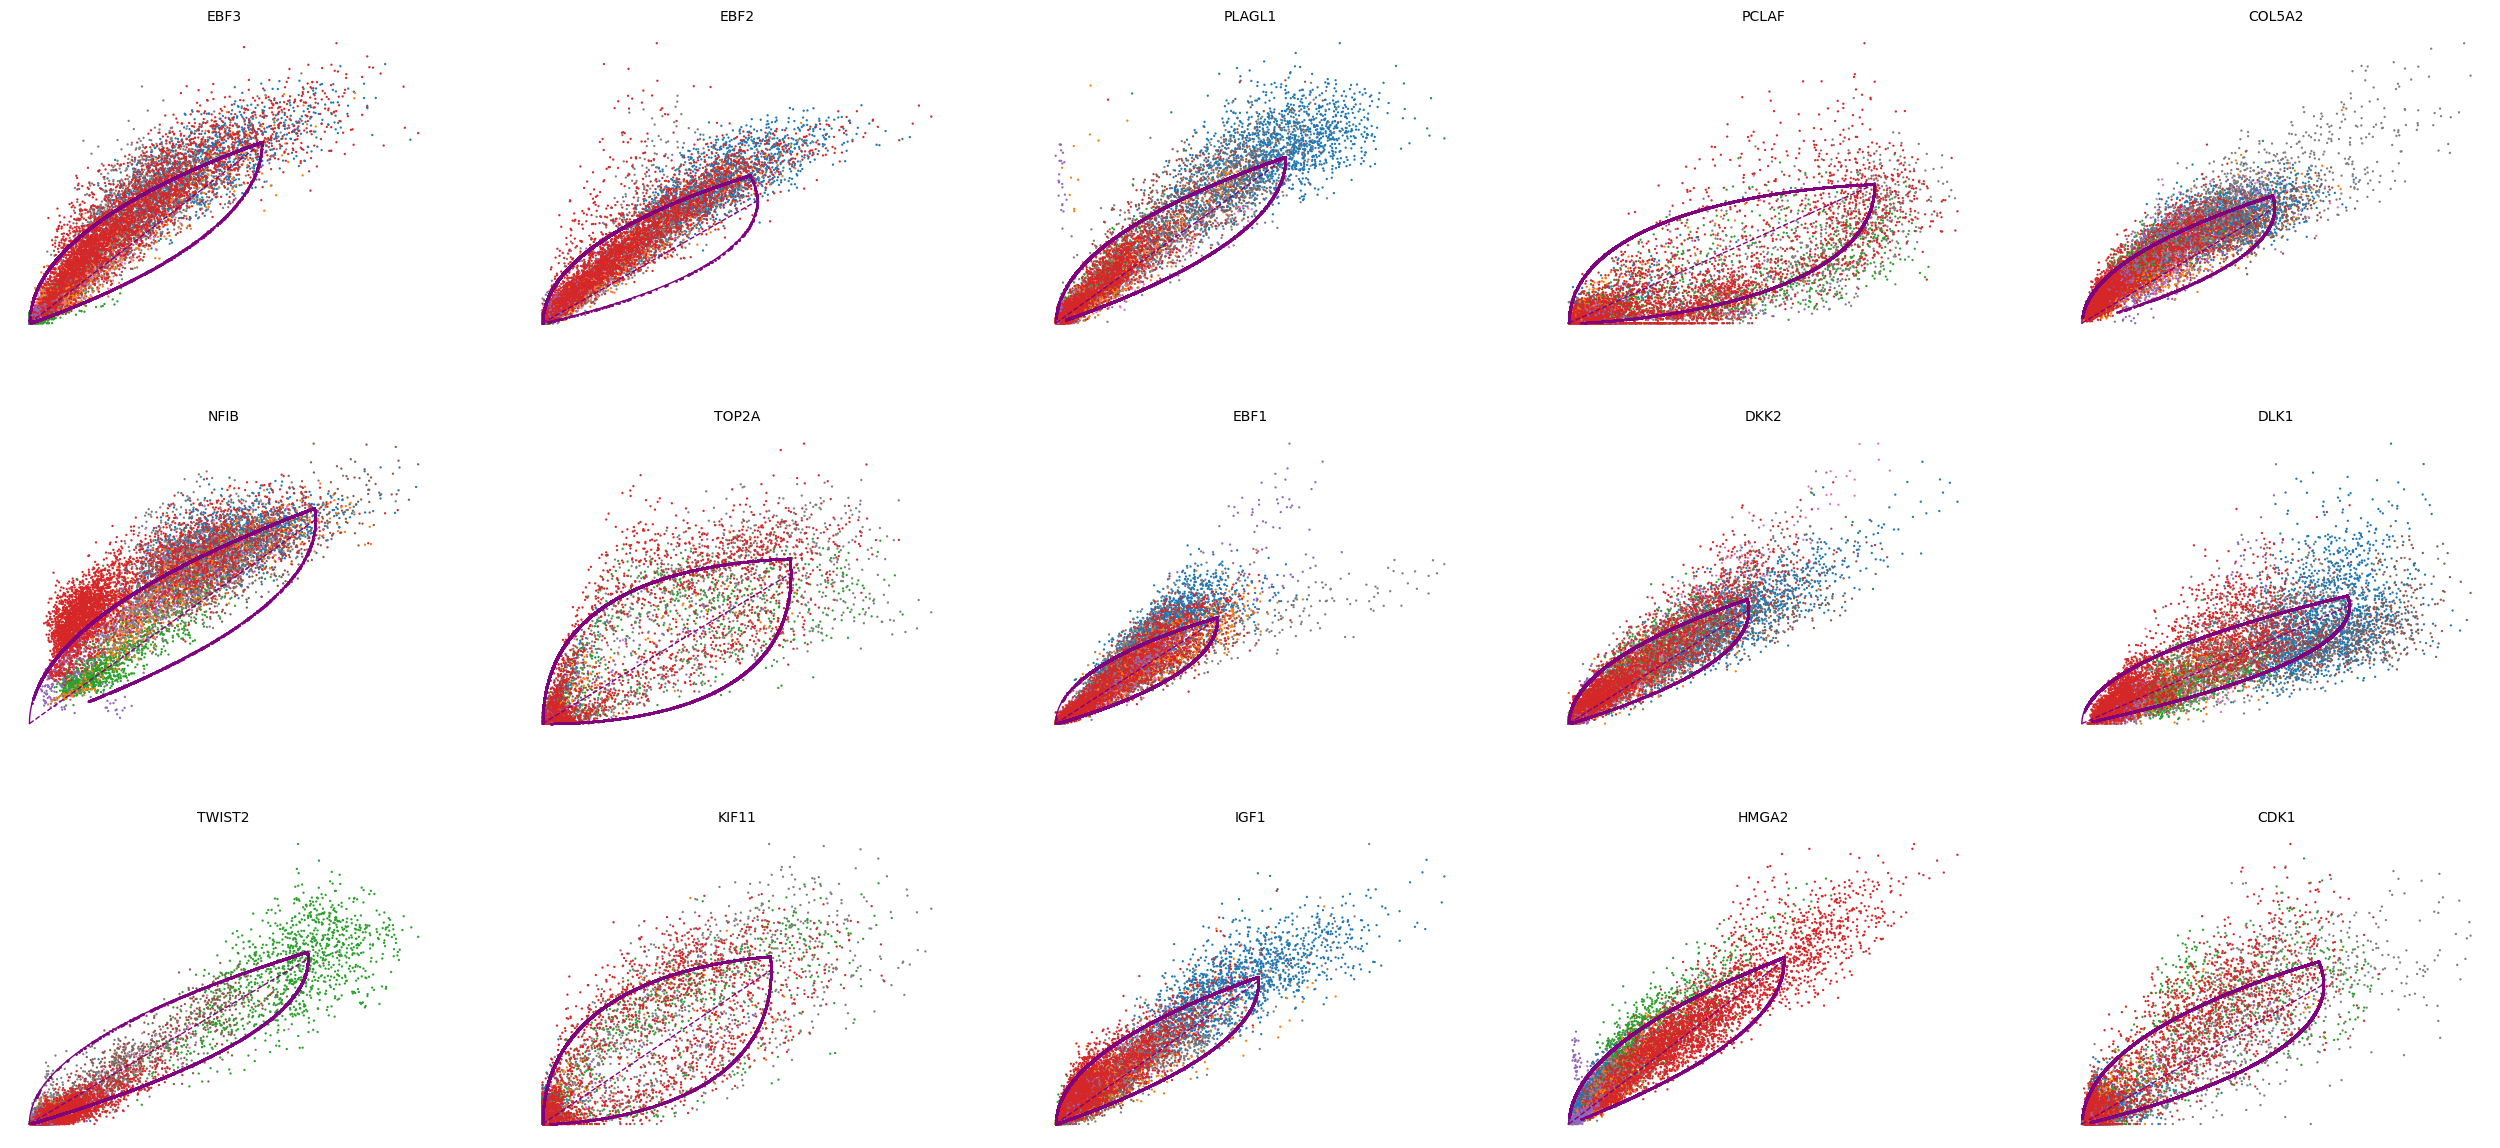

In [17]:
# top-likelihood genes phase portraits
top_genes1 = subset_adata.var['fit_likelihood'].sort_values(ascending=False).index
scv.pl.scatter(subset_adata, basis=top_genes[:15], color='cell_type', ncols=5, frameon=False)

/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWa

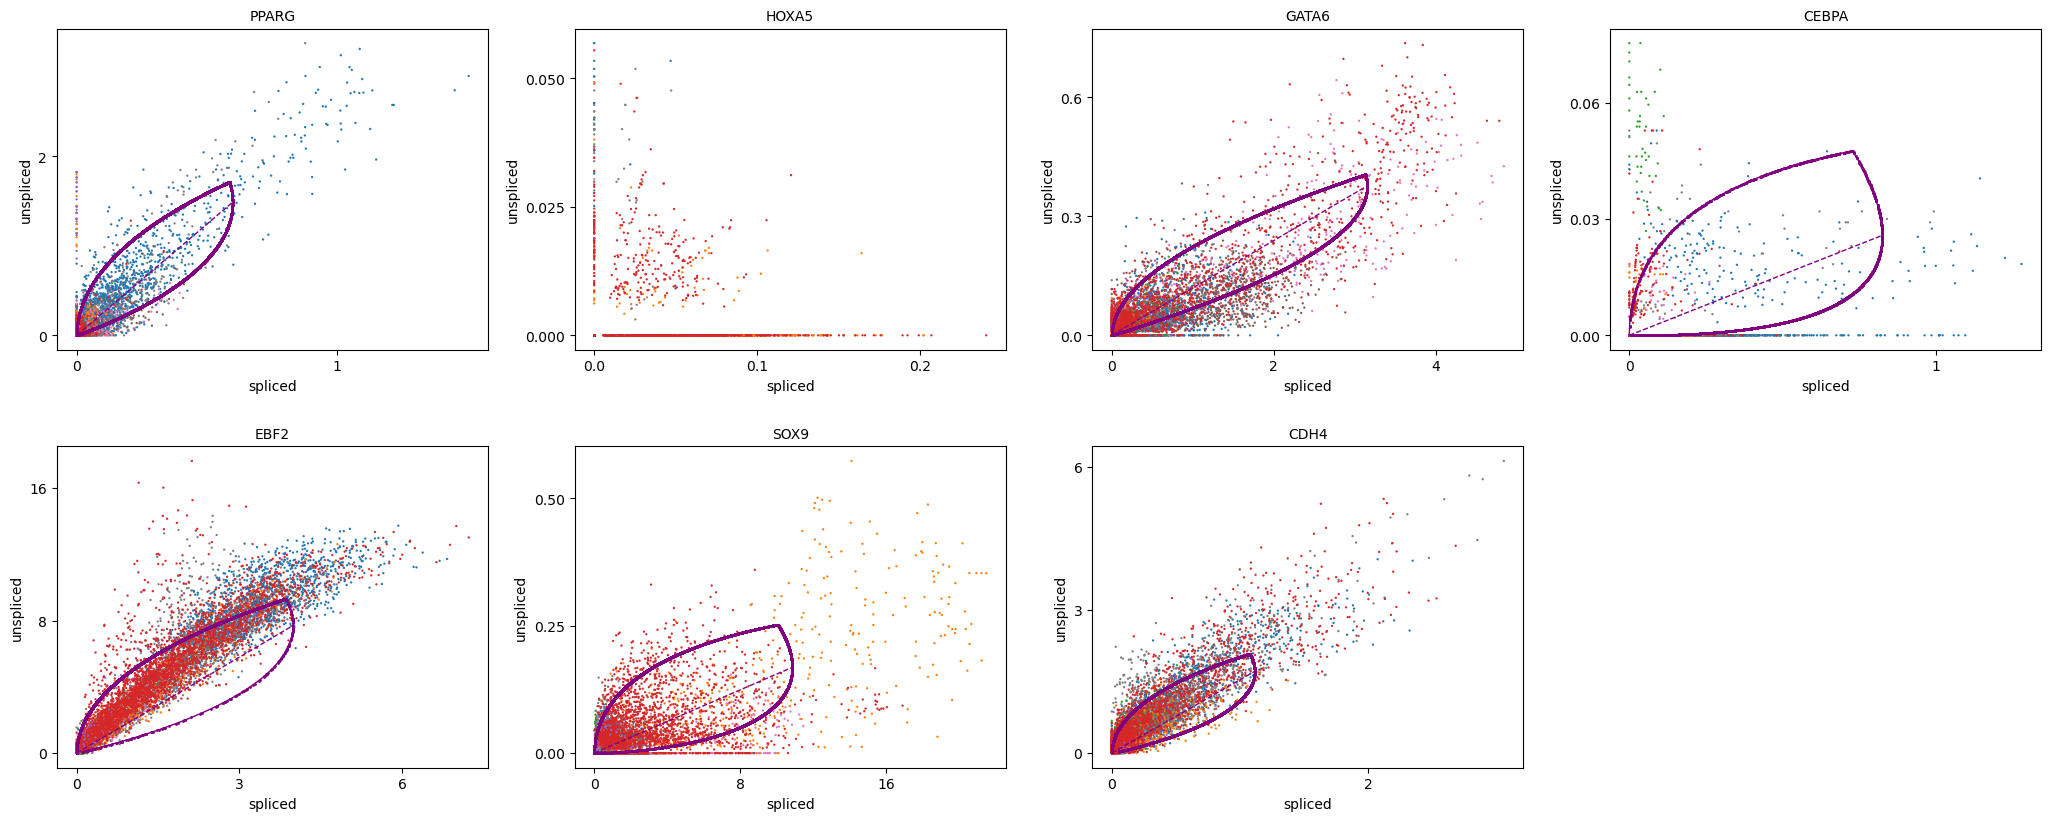

In [18]:
# BAT genes phase portraits
bat_genes = ['PPARG', 'HOXA5', 'GATA6', 'CEBPA', 'EBF2', 'SOX9', 'CDH4']
scv.pl.scatter(subset_adata, bat_genes, color='cell_type', ncols=4)

In [19]:
# cell types-specific top-likelihood genes
scv.tl.rank_dynamical_genes(subset_adata, groupby='cell_type')
cluster_top_likelihood_genes = scv.get_df(subset_adata, 'rank_dynamical_genes/names')
cluster_top_likelihood_genes.head(10)

ranking genes by cluster-specific likelihoods
    finished (0:00:09) --> added 
    'rank_dynamical_genes', sorted scores by group ids (adata.uns)


/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9366/1748735160.py:3: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  cluster_top_likelihood_genes = scv.get_df(subset_adata, 'rank_dynamical_genes/names')
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/core/_anndata.py:257: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(data.obs[key])


,Brown adipocytes,Chondrocytes,Dermis,Fibroblast progenitors,Meninges,Muscle connective tissue,Smooth muscle,Tendon
0,NFIB,EBF3,COL5A2,NFIB,TCF4,PLAGL1,COL5A2,PLAGL1
1,EBF3,NFIB,PCLAF,EBF3,MEST,COL5A2,NFIB,EBF3
2,COL5A2,EBF1,HMGA2,EBF1,NFIB,EBF1,HMGA2,PCLAF
3,EBF2,EBF2,COL1A2,EBF2,GPC3,DLK1,GPC3,TSHZ2
4,GPC3,SPATS2L,TOP2A,DKK2,COL1A2,TWIST2,COL5A1,EBF2
5,SPATS2L,COL5A2,KIF11,TOP2A,MAP1B,GPC3,TSHZ2,DLK1
6,SEMA5A,RIAN,RIAN,MEST,C430049B03RIK,POSTN,PLPP3,SEMA5A
7,COL1A2,MEST,EGFL6,DLK1,PLPP3,SEMA5A,MEG3,DKK2
8,TSHZ2,TSHZ2,PLPP3,CDK1,RIAN,NFIB,COL3A1,NFIB
9,EBF1,ZFHX3,ANXA2,RIAN,NKD1,TSHZ2,MPPED2,COL1A2


/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWa

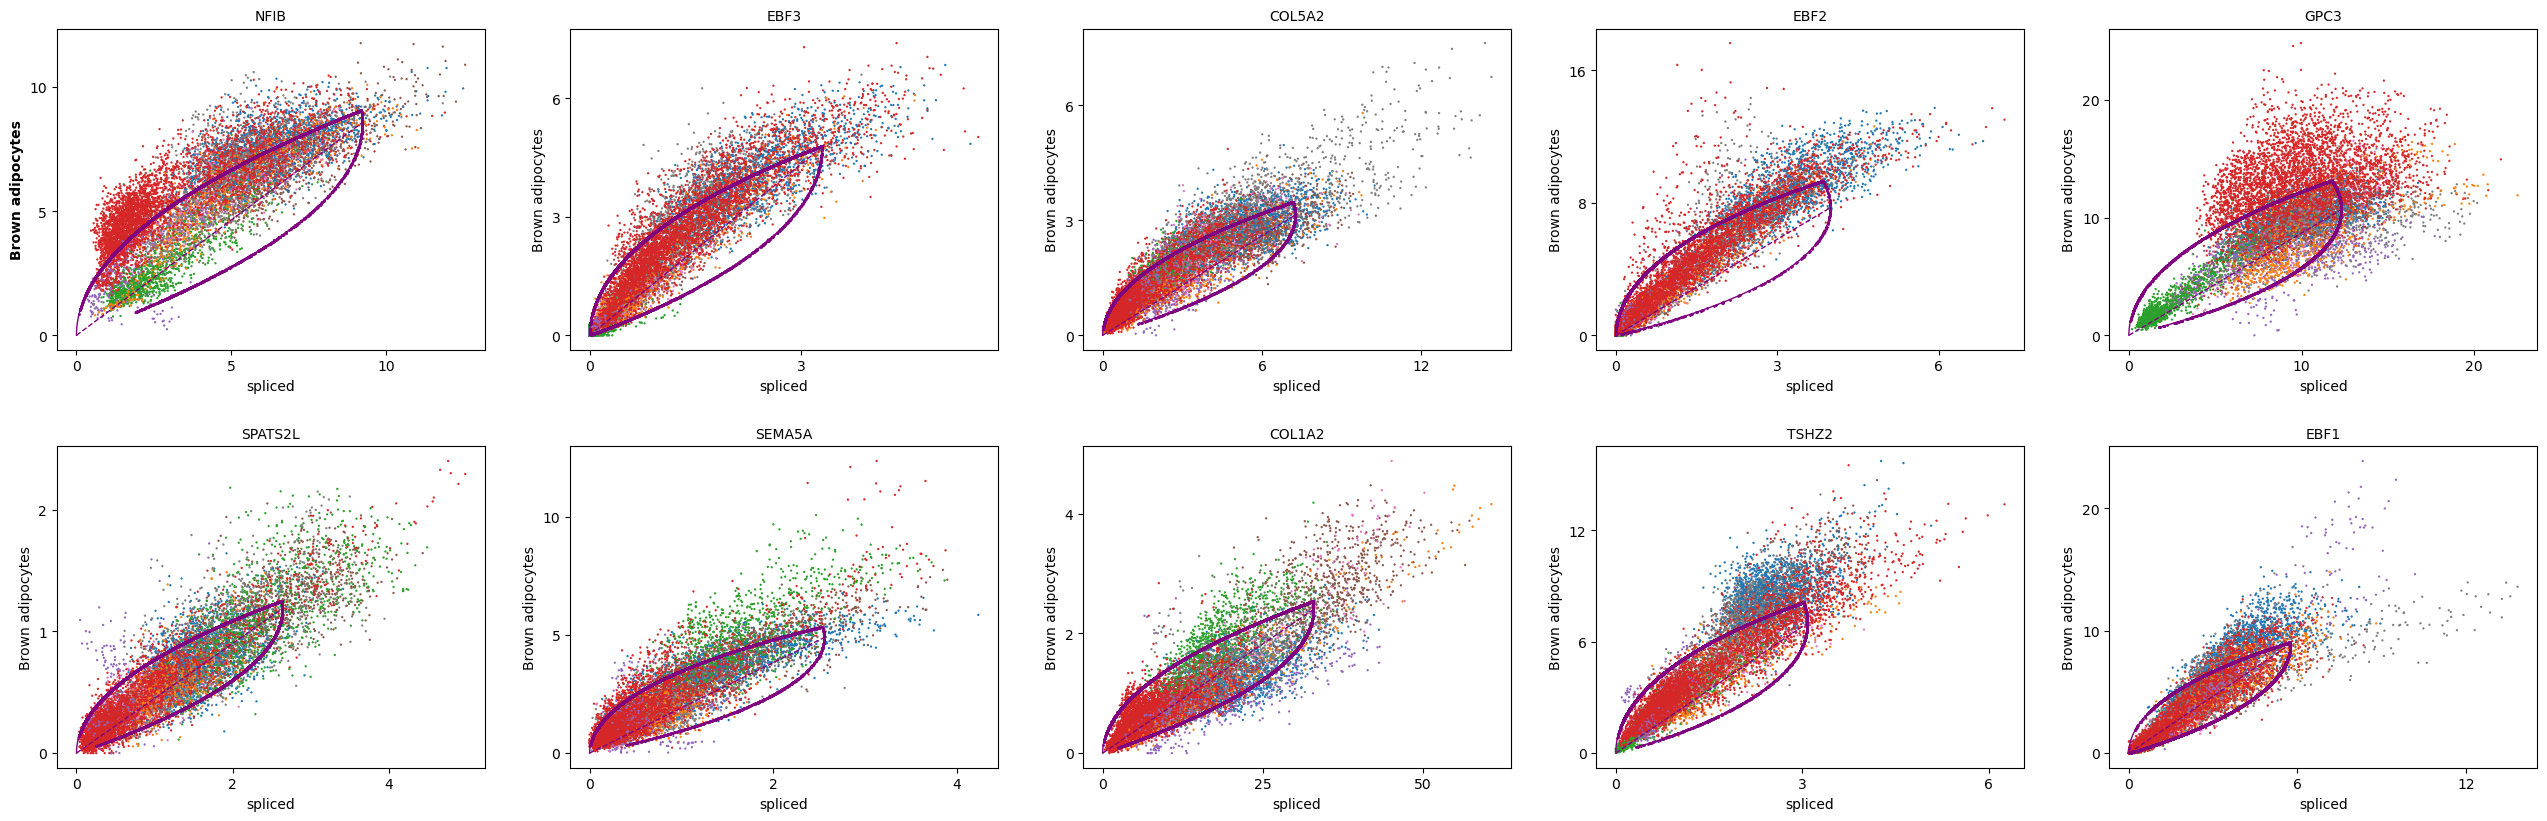

In [20]:
for cluster in ['Brown adipocytes']:
    scv.pl.scatter(subset_adata, cluster_top_likelihood_genes[cluster][:10], ylabel=cluster, ncols=5, color='cell_type')

/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.

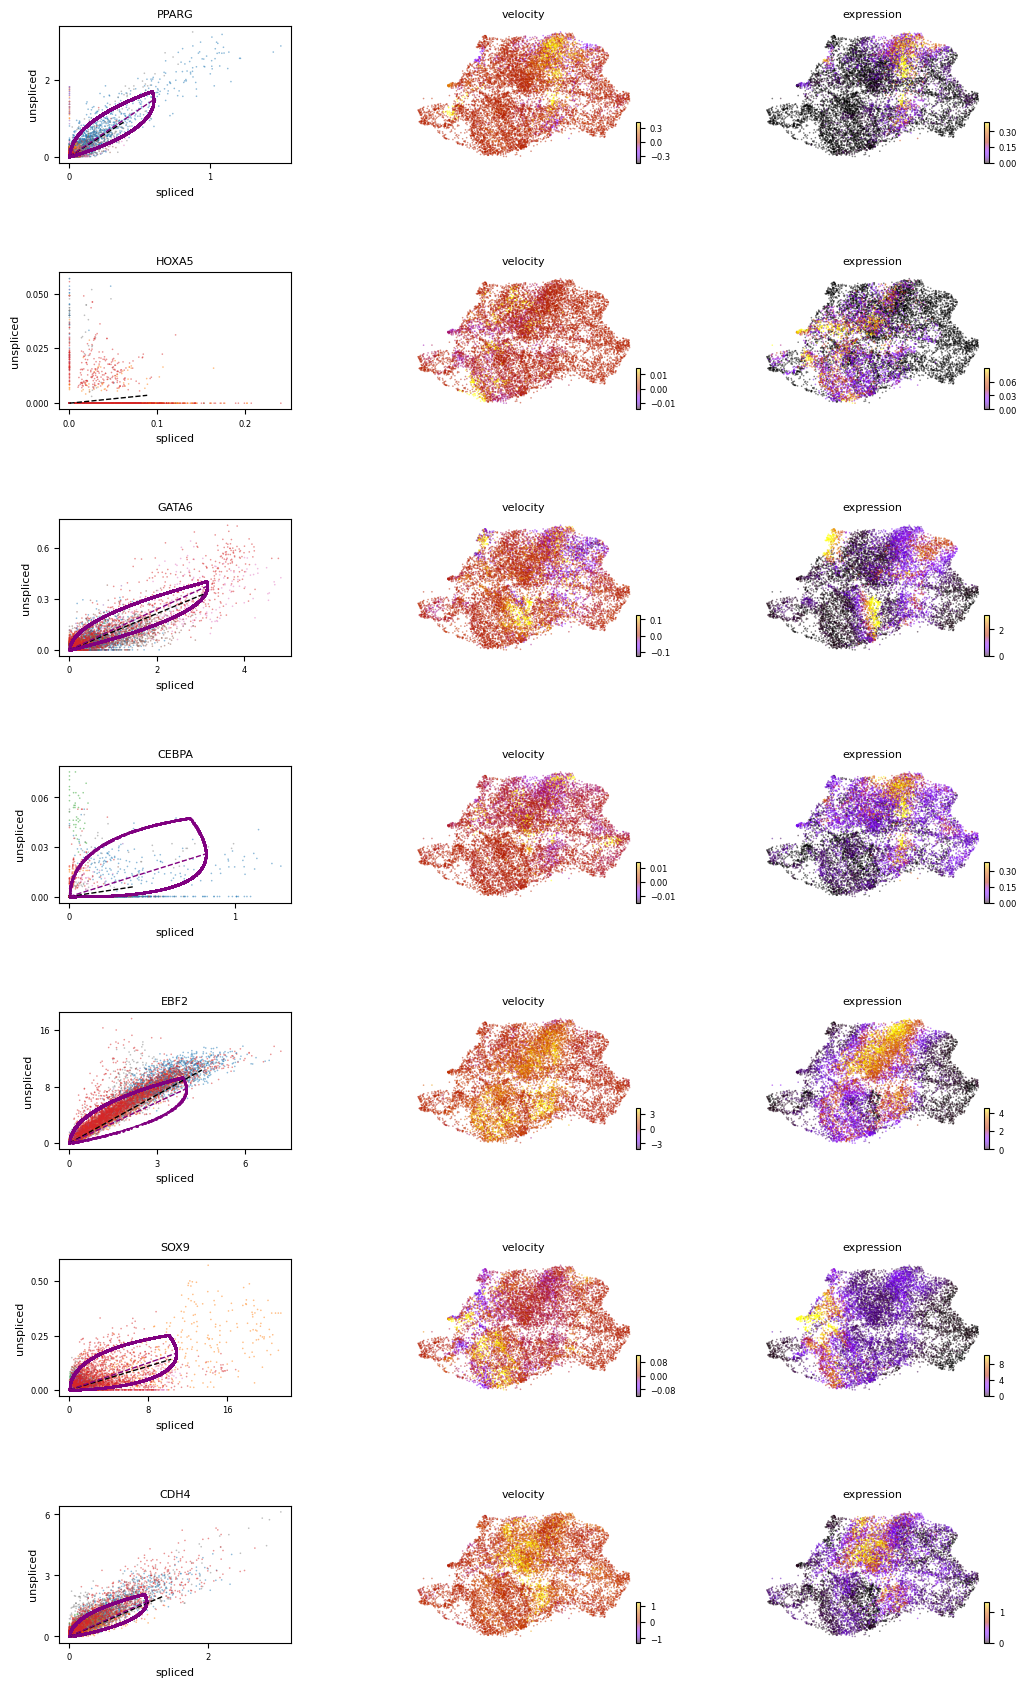

In [21]:
scv.pl.velocity(subset_adata, bat_genes, color='cell_type', color_map='gnuplot', figsize=(8,6))

In [22]:
# top 300 dynamical genes in BA cluster
top_dynamical_genes_ba = scv.get_df(subset_adata, 'rank_dynamical_genes/names')
top_dynamical_genes_ba = top_dynamical_genes_ba.iloc[:, 0]
top_dynamical_genes_ba.head(20)
top_dynamical_genes_ba.to_csv('/Users/rikac/Documents/mansfield_lab/summer_25/results/scvelo/brown_adipocytes_dynamical_genes.csv')

/var/folders/py/vj3fjhrx3c3f6dq8h2g1svr80000gn/T/ipykernel_9366/1821437858.py:2: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  top_dynamical_genes_ba = scv.get_df(subset_adata, 'rank_dynamical_genes/names')
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/core/_anndata.py:257: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(data.obs[key])


/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/envs/cr/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


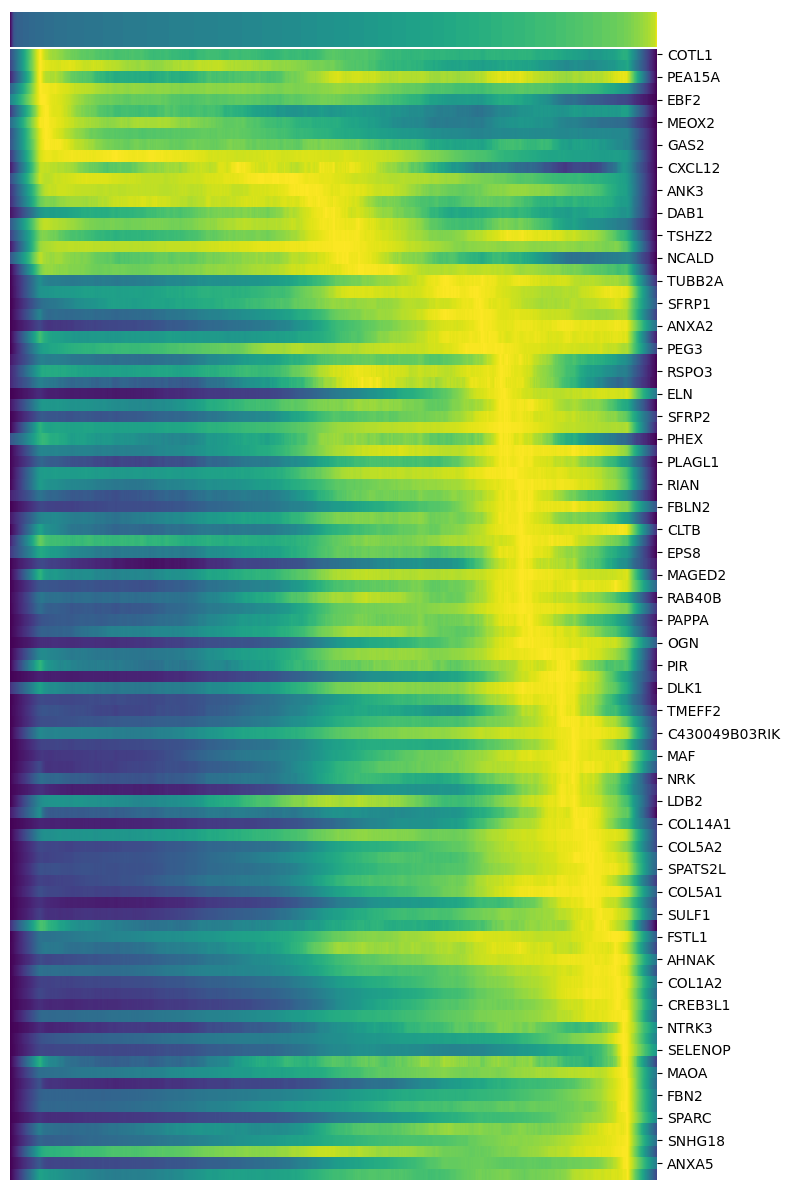

In [23]:
# heatmap of dynamical genes
scv.pl.heatmap(
    subset_adata,
    var_names=top_dynamical_genes_ba,
    sortby='latent_time',
    col_color='latent_time',
    n_convolve=1000,
    figsize=(8, 12)   
)

In [ ]:
subset_adata.write_h5ad('/Users/rikac/Documents/mansfield_lab/summer_25/bc3306_scvelo_analyzed_ver3.h5ad')